In [1]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Aditya
[nltk_data]     Raj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
import csv
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))
import matplotlib.pyplot as plt


In [3]:
vocab_size = 5000
embedding_dim = 64
max_length = 200
padding_type = 'post'
trunc_type = 'post'
oov_tok = '<OOV>'
training_portion = .8

In [4]:
articles = []
labels = []

with open("bbc-text.csv", 'r') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    next(reader)
    for row in reader:
        labels.append(row[0])
        article = row[1]
        for word in STOPWORDS:
            token = ' ' + word + ' '
            article = article.replace(token, ' ')
            article = article.replace(' ', ' ')
        articles.append(article)
print(len(labels))
print(len(articles))

2225
2225


In [5]:
train_size = int(len(articles) * training_portion)

train_articles = articles[0: train_size]
train_labels = labels[0: train_size]

validation_articles = articles[train_size:]
validation_labels = labels[train_size:]

print(train_size)
print(len(train_articles))
print(len(train_labels))
print(len(validation_articles))
print(len(validation_labels))

1780
1780
1780
445
445


In [6]:
tokenizer = Tokenizer(num_words = vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_articles)
word_index = tokenizer.word_index

In [7]:
dict(list(word_index.items())[0:10])

{'<OOV>': 1,
 'said': 2,
 'mr': 3,
 'would': 4,
 'year': 5,
 'also': 6,
 'people': 7,
 'new': 8,
 'us': 9,
 'one': 10}

In [8]:
len(word_index)

27270

In [9]:
train_sequences  = tokenizer.texts_to_sequences(train_articles)

print(train_sequences[10])

[2432, 1, 225, 4995, 22, 641, 586, 225, 4995, 1, 1, 1662, 1, 1, 2432, 22, 564, 1, 1, 140, 278, 1, 140, 278, 796, 822, 662, 2308, 1, 1145, 1693, 1, 1720, 4996, 1, 1, 1, 1, 1, 4738, 1, 1, 122, 4514, 1, 2, 2874, 1505, 352, 4739, 1, 52, 341, 1, 352, 2171, 3962, 41, 22, 3795, 1, 1, 1, 1, 542, 1, 1, 1, 835, 631, 2367, 347, 4740, 1, 365, 22, 1, 787, 2368, 1, 4302, 138, 10, 1, 3666, 682, 3532, 1, 22, 1, 414, 822, 662, 1, 90, 13, 633, 1, 225, 4995, 1, 599, 1, 1693, 1021, 1, 4997, 807, 1864, 117, 1, 1, 1, 2974, 22, 1, 99, 278, 1, 1605, 4998, 542, 492, 1, 1442, 4741, 779, 1320, 1, 1861, 10, 33, 641, 319, 1, 62, 478, 564, 301, 1506, 22, 479, 1, 1, 1665, 1, 797, 1, 3067, 1, 1364, 6, 1, 2432, 564, 22, 2971, 4735, 1, 1, 1, 1, 1, 850, 39, 1825, 675, 297, 26, 979, 1, 882, 22, 361, 22, 13, 301, 1506, 1342, 374, 20, 63, 883, 1097, 4303, 247]


In [10]:
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [11]:
print(train_sequences[10])

[2432, 1, 225, 4995, 22, 641, 586, 225, 4995, 1, 1, 1662, 1, 1, 2432, 22, 564, 1, 1, 140, 278, 1, 140, 278, 796, 822, 662, 2308, 1, 1145, 1693, 1, 1720, 4996, 1, 1, 1, 1, 1, 4738, 1, 1, 122, 4514, 1, 2, 2874, 1505, 352, 4739, 1, 52, 341, 1, 352, 2171, 3962, 41, 22, 3795, 1, 1, 1, 1, 542, 1, 1, 1, 835, 631, 2367, 347, 4740, 1, 365, 22, 1, 787, 2368, 1, 4302, 138, 10, 1, 3666, 682, 3532, 1, 22, 1, 414, 822, 662, 1, 90, 13, 633, 1, 225, 4995, 1, 599, 1, 1693, 1021, 1, 4997, 807, 1864, 117, 1, 1, 1, 2974, 22, 1, 99, 278, 1, 1605, 4998, 542, 492, 1, 1442, 4741, 779, 1320, 1, 1861, 10, 33, 641, 319, 1, 62, 478, 564, 301, 1506, 22, 479, 1, 1, 1665, 1, 797, 1, 3067, 1, 1364, 6, 1, 2432, 564, 22, 2971, 4735, 1, 1, 1, 1, 1, 850, 39, 1825, 675, 297, 26, 979, 1, 882, 22, 361, 22, 13, 301, 1506, 1342, 374, 20, 63, 883, 1097, 4303, 247]


In [12]:
print(train_padded[10])

[2432    1  225 4995   22  641  586  225 4995    1    1 1662    1    1
 2432   22  564    1    1  140  278    1  140  278  796  822  662 2308
    1 1145 1693    1 1720 4996    1    1    1    1    1 4738    1    1
  122 4514    1    2 2874 1505  352 4739    1   52  341    1  352 2171
 3962   41   22 3795    1    1    1    1  542    1    1    1  835  631
 2367  347 4740    1  365   22    1  787 2368    1 4302  138   10    1
 3666  682 3532    1   22    1  414  822  662    1   90   13  633    1
  225 4995    1  599    1 1693 1021    1 4997  807 1864  117    1    1
    1 2974   22    1   99  278    1 1605 4998  542  492    1 1442 4741
  779 1320    1 1861   10   33  641  319    1   62  478  564  301 1506
   22  479    1    1 1665    1  797    1 3067    1 1364    6    1 2432
  564   22 2971 4735    1    1    1    1    1  850   39 1825  675  297
   26  979    1  882   22  361   22   13  301 1506 1342  374   20   63
  883 1097 4303  247    0    0    0    0    0    0    0    0    0    0
    0 

In [13]:
validation_sequences = tokenizer.texts_to_sequences(validation_articles)
validation_padded = pad_sequences(validation_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(len(validation_sequences))
print(validation_padded.shape)

445
(445, 200)


In [14]:
print(set(labels))

{'sport', 'tech', 'entertainment', 'politics', 'business'}


In [15]:
label_tokenizer = Tokenizer()
label_tokenizer.fit_on_texts(labels)

training_label_seq = np.array(label_tokenizer.texts_to_sequences(train_labels))
validation_label_seq = np.array(label_tokenizer.texts_to_sequences(validation_labels))

In [16]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.Bidirectional(tf.keras.layers.SimpleRNN(embedding_dim)),
    tf.keras.layers.Dense(embedding_dim, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

num_epochs = 10

history = model.fit(train_padded, training_label_seq, epochs=num_epochs, validation_data=(validation_padded, validation_label_seq), verbose=2)


Epoch 1/10
56/56 - 6s - 110ms/step - accuracy: 0.2270 - loss: 1.6455 - val_accuracy: 0.2809 - val_loss: 1.5600
Epoch 2/10
56/56 - 3s - 45ms/step - accuracy: 0.3646 - loss: 1.5156 - val_accuracy: 0.4270 - val_loss: 1.4678
Epoch 3/10
56/56 - 3s - 48ms/step - accuracy: 0.6966 - loss: 0.9843 - val_accuracy: 0.6337 - val_loss: 0.9867
Epoch 4/10
56/56 - 3s - 45ms/step - accuracy: 0.9551 - loss: 0.2727 - val_accuracy: 0.7326 - val_loss: 0.6894
Epoch 5/10
56/56 - 2s - 39ms/step - accuracy: 0.9983 - loss: 0.0320 - val_accuracy: 0.7438 - val_loss: 0.6850
Epoch 6/10
56/56 - 2s - 38ms/step - accuracy: 1.0000 - loss: 0.0075 - val_accuracy: 0.7551 - val_loss: 0.6797
Epoch 7/10
56/56 - 2s - 37ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.7573 - val_loss: 0.6849
Epoch 8/10
56/56 - 2s - 40ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.7663 - val_loss: 0.6968
Epoch 9/10
56/56 - 2s - 39ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.7640 - val_loss: 0.7087
Epoch 10/

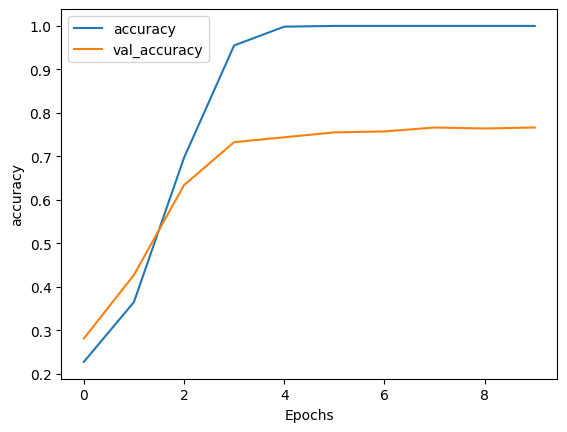

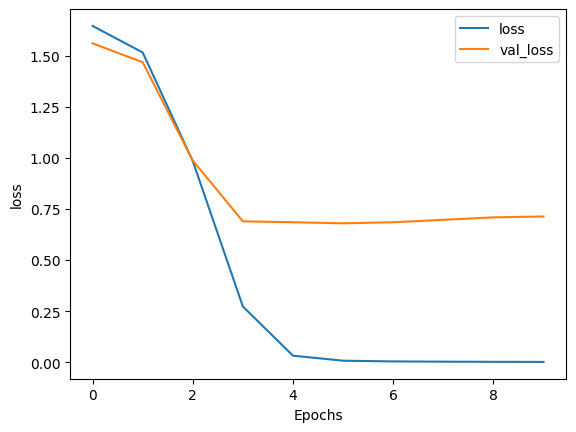

In [18]:
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

# Using LSTM Model


In [19]:
model = tf.keras.Sequential([

    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(embedding_dim)),
    tf.keras.layers.Dense(embedding_dim, activation='relu'),

    tf.keras.layers.Dense(6, activation='softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

num_epochs = 10

history = model.fit(train_padded, training_label_seq, epochs=num_epochs, validation_data=(validation_padded, validation_label_seq), verbose=2)


Epoch 1/10
56/56 - 7s - 129ms/step - accuracy: 0.3360 - loss: 1.5345 - val_accuracy: 0.6607 - val_loss: 1.1943
Epoch 2/10
56/56 - 4s - 68ms/step - accuracy: 0.6938 - loss: 0.7926 - val_accuracy: 0.6090 - val_loss: 0.8187
Epoch 3/10
56/56 - 4s - 68ms/step - accuracy: 0.9140 - loss: 0.2743 - val_accuracy: 0.9169 - val_loss: 0.2627
Epoch 4/10
56/56 - 4s - 68ms/step - accuracy: 0.9770 - loss: 0.0800 - val_accuracy: 0.8809 - val_loss: 0.3274
Epoch 5/10
56/56 - 4s - 72ms/step - accuracy: 0.9758 - loss: 0.0825 - val_accuracy: 0.8921 - val_loss: 0.2859
Epoch 6/10
56/56 - 4s - 70ms/step - accuracy: 0.9978 - loss: 0.0230 - val_accuracy: 0.9483 - val_loss: 0.1865
Epoch 7/10
56/56 - 4s - 68ms/step - accuracy: 0.9994 - loss: 0.0074 - val_accuracy: 0.9528 - val_loss: 0.2080
Epoch 8/10
56/56 - 4s - 66ms/step - accuracy: 0.9994 - loss: 0.0048 - val_accuracy: 0.9416 - val_loss: 0.2016
Epoch 9/10
56/56 - 4s - 66ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9483 - val_loss: 0.1943
Epoch 10/

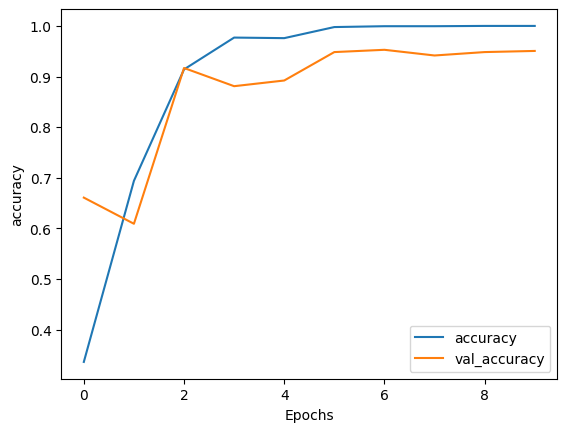

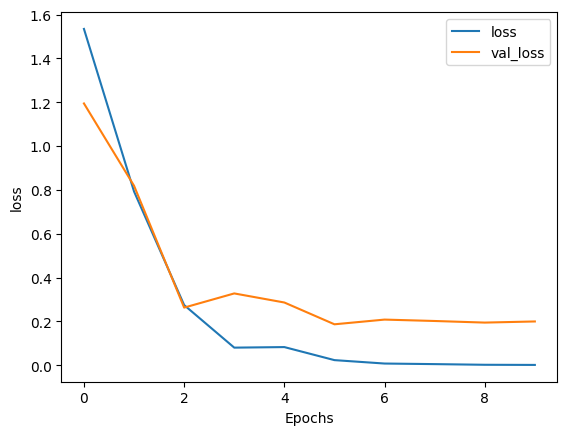

In [21]:
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")